# Tools 실험

In [1]:
from AutoFineTuner.tool import codeLauncher
from AutoFineTuner.tool import codeMaker
from AutoFineTuner.tool import codeReader
from AutoFineTuner.tool import llms

[engine] __init__.py 초기화됨


In [3]:
response = llms.llm_list["gpt-4.1-nano"].invoke("나는 누구인가?")
print(response.content)

반갑습니다! "나는 누구인가?"라는 질문은 매우 깊고 철학적인 질문입니다. 자신의 정체성과 존재 이유를 고민하는 것은 삶의 중요한 부분이죠. 혹시 더 구체적인 질문이나, 자신에 대해 더 이야기하고 싶은 내용이 있다면 말씀해 주세요. 함께 생각해보거나 도와드릴 수 있는 부분이 있을 거예요.


# codeAnalyzer 코드 실험

In [7]:
# codeAnalyzer 코드 실험
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

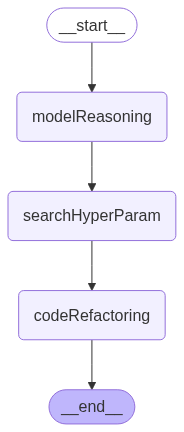

In [8]:
from langgraph.graph import END, StateGraph, START
from typing import Annotated, List
from typing_extensions import TypedDict

class CodeAnalyerState(TypedDict):
    sourceCode: Annotated[str, "sourceCode"]
    modelInfo : Annotated[str, "modelInfo"]
    hyperParams: Annotated[str, "hyperParams"]
    userPrompt: Annotated[str, "userPrompt"]
    refactoredCode: Annotated[str, "refactoredCode"]
    
def modelReasoning(state : CodeAnalyerState):
    return {"modelInfo" : "..."}

def searchHyperParam(state : CodeAnalyerState):
    return {"hyperParams" : "..."}

def codeRefactoring(state : CodeAnalyerState):
    return {"refactoredCode" : "..."}


workflow = StateGraph(CodeAnalyerState)
workflow.add_node("modelReasoning", modelReasoning)
workflow.add_node("searchHyperParam", searchHyperParam)
workflow.add_node("codeRefactoring", codeRefactoring)

workflow.add_edge(START, "modelReasoning")
workflow.add_edge("modelReasoning", "searchHyperParam")
workflow.add_edge("searchHyperParam", "codeRefactoring")
workflow.add_edge("codeRefactoring", END)
workflow.compile()

In [11]:
target_path = "/Users/yujin/Desktop/코딩shit/python_projects/opensource/target.py"
traget_contents = codeReader.read_text_strict(target_path)
traget_contents

'import pandas as pd\n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.pipeline import FeatureUnion, Pipeline\nfrom sklearn.preprocessing import FunctionTransformer\nfrom sklearn.metrics import roc_auc_score\n\nfrom xgboost import XGBClassifier\n\n\ntrain = pd.read_csv(\'./datas/train.csv\', encoding=\'utf-8-sig\')\ntest = pd.read_csv(\'./datas/test.csv\', encoding=\'utf-8-sig\')\nX = train[[\'title\', \'full_text\']]\ny = train[\'generated\']\nX_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)\n\n# TF-IDF 벡터화\nget_title = FunctionTransformer(lambda x: x[\'title\'], validate=False)\nget_text = FunctionTransformer(lambda x: x[\'full_text\'], validate=False)\n\nvectorizer = FeatureUnion([\n    (\'title\', Pipeline([(\'selector\', get_title),\n                        (\'tfidf\', TfidfVectorizer(ngram_range=(1,2), max_features=3000))])),\n    (\'full_text\', Pip

In [9]:
llm_list = llms.llm_list

In [19]:
prompt_to_reasoning_code = PromptTemplate.from_template(
    """
    # 지시사항
    소스코드에서 AI모델가 어떤 라이브러리, 어떤 일을 위한 모델인지 판단한다.
    이 분석내용을 기반으로 이 소스코드에서 파인튜닝할 하이퍼파라미터를 선정할것이다.
    너는 소스코드를 기반으로 코드를 분석해서 소스코드의 훈련과정에 대한 분석한 내용을 제공해야한다.

    # 소스코드
    {sourceCode}

    # Answer
    ...
""",
input_variables="sourceCode"
)


TypeError: langchain_core.prompts.prompt.PromptTemplate() got multiple values for keyword argument 'input_variables'

In [16]:
# 모델 이해하기
# basic 워크플로우로 사용.
def modelReasoning(state : CodeAnalyerState):
    sourceCode = state["sourceCode"]
    chain = (
        {"sourceCode" : sourceCode}
        | prompt_to_reasoning_code
        | llm_list["gpt-4.1"]
        | StrOutputParser
    )
    modelInfo = chain.invoke({"sourceCode" : sourceCode})
    return {"modelInfo" : modelInfo}


In [17]:
state = CodeAnalyerState()
state['sourceCode'] = target_path
modelInfo = modelReasoning(state)
modelInfo

TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'>

In [ ]:
# 하이퍼파라미터 찾기, 선정하기
def searchHyperParam(state : CodeAnalyerState):
    return {"hyperParams" : "..."}

In [ ]:
# 찾은 하이퍼파라미터가 인자화된, 리펙토링된 코드를 반환받기.
def codeRefactoring(state : CodeAnalyerState):
    return {"refactoredCode" : "..."}

In [10]:
print(result)

```python
import os
import sys
import json
import argparse
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
import joblib  # For saving model/vectorizer

def main():
    parser = argparse.ArgumentParser(description="AutoFineTuner-compatible training script for TFIDF+XGBoost")

    # --- 주요 하이퍼파라미터 및 실행 관련 인자 정의 (기본값 = 기존 코드 유지) ---
    parser.add_argument('--ngram_range_title', type=str, default='1,2',
                        help='ngram_range for title TFIDF (format: min,max), default=1,2')
    parser.add_argument('--max_features_title', type=int, default=3000,
                        help='max_features for title TFIDF, default=3000')
    parser.add_argument('--ngram_range_text', type=str, default='1,2',
                 

# manager 코드 실험

In [ ]:
# manager 코드 실험
